# Głębokie Uczenie w Praktyce
## Laboratorium 7
### Mateusz Horczak

In [9]:
from numpy.exceptions import VisibleDeprecationWarning
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from random import randint
from numpy import array, argmax
from tensorflow.keras import preprocessing
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, SimpleRNN, Dense, Input
import warnings

warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)

#### Ćwiczenie 1a Uruchomienie kodu z RNN - Echo sequence prediction problem - przygotowanie danych

In [10]:
# generate a sequence of random numbers in [0, n_features)
def generate_sequence(length, n_features):
    return [randint(0, n_features - 1) for _ in range(length)]


# one hot encode sequence
def one_hot_encode(sequence, n_features):
    encoding = list()
    for value in sequence:
        vector = [0 for _ in range(n_features)]
        vector[value] = 1
        encoding.append(vector)
    return array(encoding)


# decode a one hot encoded string
def one_hot_decode(encoded_seq):
    return [argmax(vector) for vector in encoded_seq]


# generate example for lstm
def generate_example(length, n_features, out_index):
    sequence = generate_sequence(length, n_features)
    encoded = one_hot_encode(sequence, n_features)
    X = encoded.reshape((1, length, n_features))
    y = encoded[out_index].reshape(1, n_features)
    return X, y

In [11]:
seq1 = generate_sequence(5, 10)
print(seq1)

[7, 4, 5, 7, 1]


In [12]:
encoded_seq = one_hot_encode(seq1, 10)
print(encoded_seq)

[[0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 0 0]]


In [13]:
length = 5
n_features = 10
out_index = 3
X, y = generate_example(length, n_features, out_index)
print("X shape:", X.shape)
print("X:\n", X)
print("y shape:", y.shape)
print("y:\n", y)
print("Decoded expected output:", one_hot_decode(y))

X shape: (1, 5, 10)
X:
 [[[0 1 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0 1 0 0]
  [0 0 0 0 1 0 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 1]
  [0 0 0 0 0 0 0 0 1 0]]]
y shape: (1, 10)
y:
 [[0 0 0 0 0 0 0 0 0 1]]
Decoded expected output: [np.int64(9)]


#### Ćwiczenie 1b Uruchomienie kodu z RNN - Echo sequence prediction problem – budowa modelu, ewaluacja i predykcja

In [14]:
length = 5
n_features = 10
out_index = 2

# Budowa modelu LSTM
model = Sequential()
model.add(Input(shape=(length, n_features)))
model.add(LSTM(25))
model.add(Dense(n_features, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
_ = model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 25)             │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,860 (15.08 KB)

 Trainable params: 3,860 (15.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Trening
for i in range(100):
    X, y = generate_example(length, n_features, out_index)
    model.fit(X, y, epochs=1, verbose=0)

In [16]:
# Ewaluacja
correct = 0
Xs = []
ys = []

for i in range(100):
    X, y = generate_example(length, n_features, out_index)
    Xs.append(X[0])
    ys.append(y[0])

Xs = np.array(Xs)
Xs = tf.cast(Xs, tf.float32)

yhat_all = model.predict(Xs, verbose=0)

for i in range(100):
    if one_hot_decode([yhat_all[i]]) == one_hot_decode([ys[i]]):
        correct += 1

print('Accuracy: %.2f%%' % ((correct / 100.0) * 100))

Accuracy: 13.00%


In [17]:
# Predykcja
X, y = generate_example(length, n_features, out_index)
X = tf.cast(X, tf.float32)
yhat = model.predict(X, verbose=0)

print('Predykcja na nowych danych')
seq_decoded = [int(x) for x in one_hot_decode(X[0])]
print('Sequence:', seq_decoded)
print('Expected:', int(one_hot_decode(y)[0]))
print('Predicted:', int(one_hot_decode(yhat)[0]))

Predykcja na nowych danych
Sequence: [4, 2, 4, 7, 8]
Expected: 4
Predicted: 4


#### Ćwiczenie 2

In [18]:
max_features = 10000
maxlen = 200
embedding_dim = 32

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

In [19]:
# return_sequences=True
model_true = Sequential()
model_true.add(Input(shape=(maxlen,)))
model_true.add(Embedding(max_features, embedding_dim))
model_true.add(SimpleRNN(32, return_sequences=True))
model_true.add(Dense(1, activation='sigmoid'))
_ = model_true.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 200, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200, 1)         │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# return_sequences=False
model_false = Sequential()
model_false.add(Input(shape=(maxlen,)))
model_false.add(Embedding(max_features, embedding_dim))
model_false.add(SimpleRNN(32, return_sequences=False))
model_false.add(Dense(1, activation='sigmoid'))
_ = model_false.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# SimpleRNN + Embedding
model = Sequential()
model.add(Input(shape=(maxlen,)))
model.add(Embedding(max_features, embedding_dim))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
_ = model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Trening
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - acc: 0.7031 - loss: 0.5598 - val_acc: 0.6366 - val_loss: 0.7380
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - acc: 0.8377 - loss: 0.3814 - val_acc: 0.8012 - val_loss: 0.4368
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - acc: 0.8657 - loss: 0.3251 - val_acc: 0.8538 - val_loss: 0.3575
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - acc: 0.8936 - loss: 0.2702 - val_acc: 0.8442 - val_loss: 0.3630
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - acc: 0.9215 - loss: 0.2076 - val_acc: 0.8582 - val_loss: 0.4019
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - acc: 0.9410 - loss: 0.1625 - val_acc: 0.7500 - val_loss: 0.5672
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - acc: 0.9595 - loss: 0.1166 - val_acc: 0.8252 - val_loss: 0.5097
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - acc: 0.9758 - loss: 0.0763 - val_acc: 0.8354 - val_loss: 0.4924
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/

#### Automatyzacja różnych parametrów

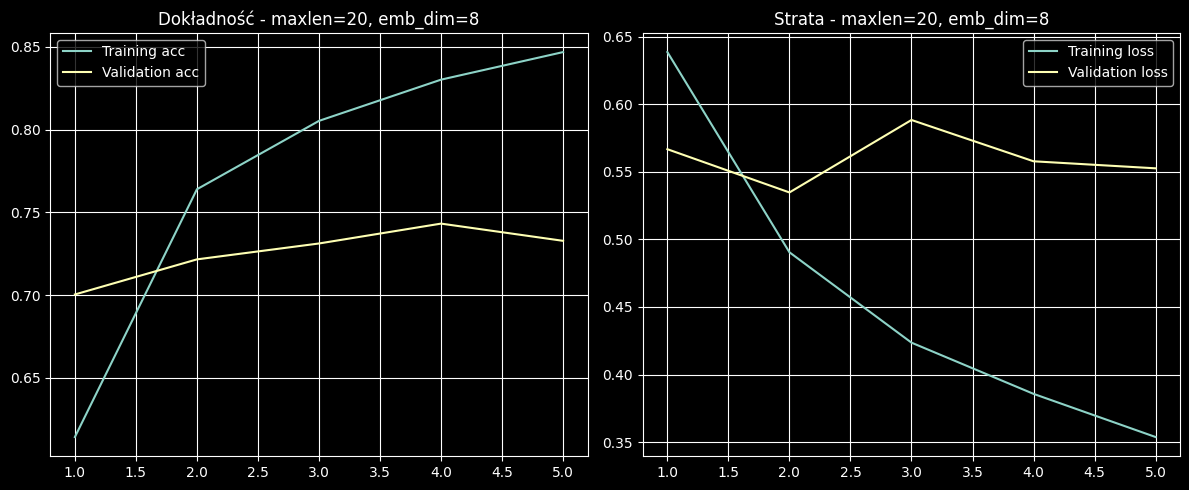

maxlen=20, emb=8 → val_acc=0.7328


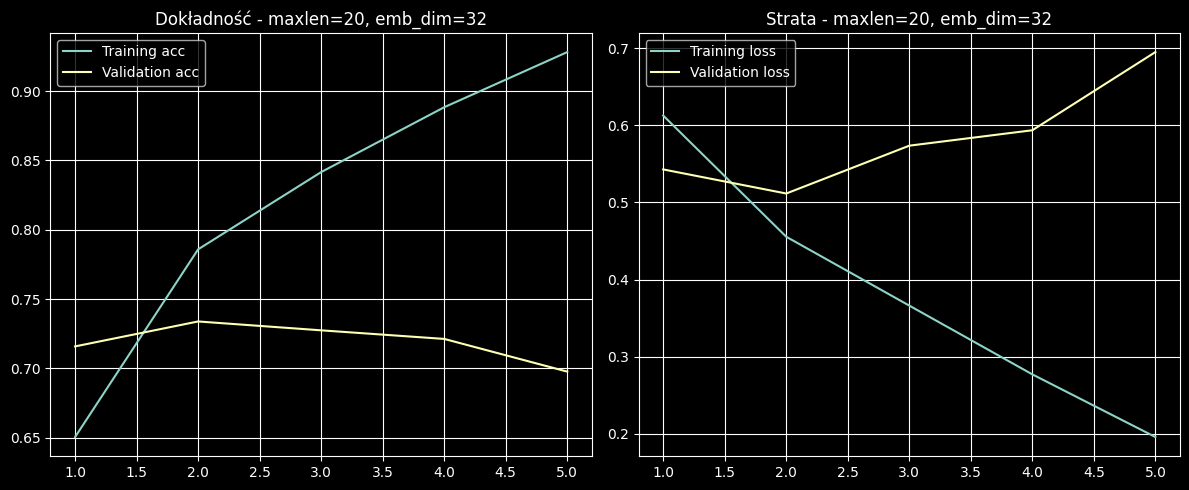

maxlen=20, emb=32 → val_acc=0.6976


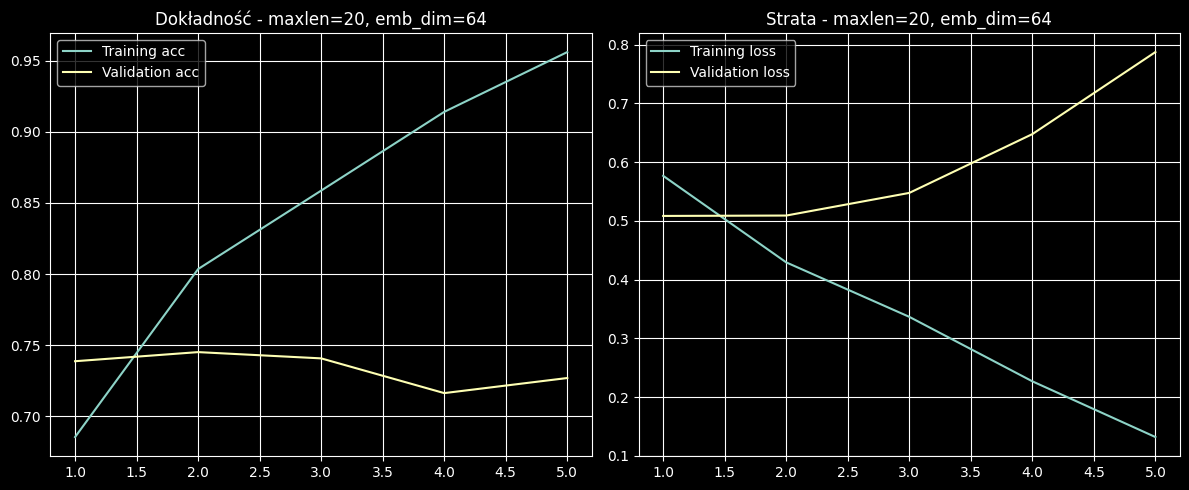

maxlen=20, emb=64 → val_acc=0.7270


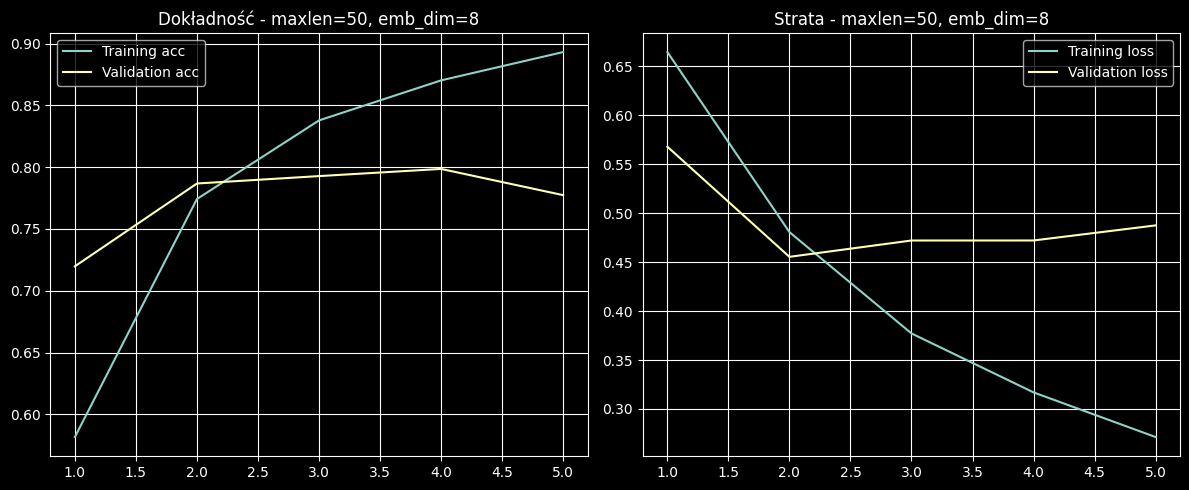

maxlen=50, emb=8 → val_acc=0.7774


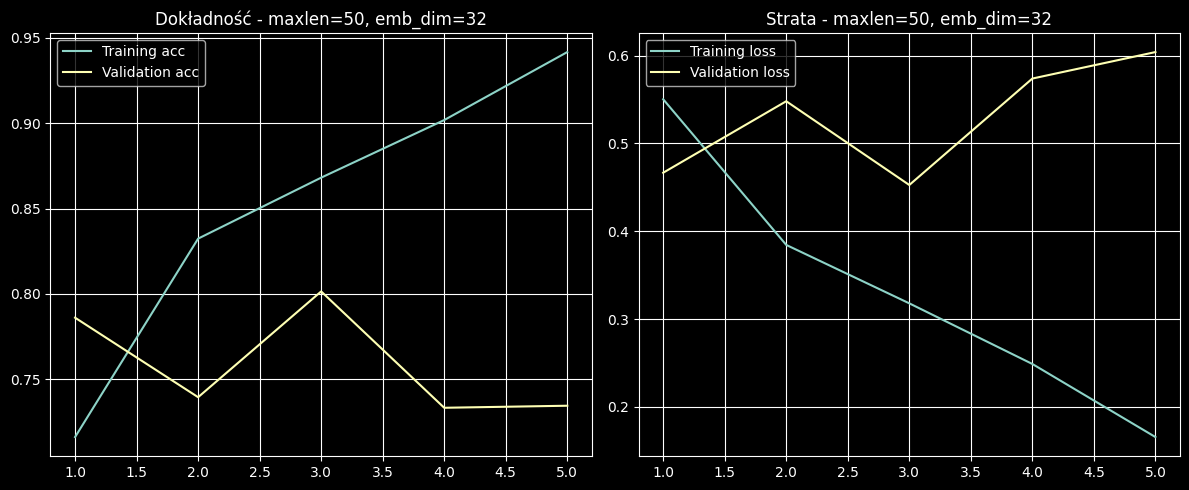

maxlen=50, emb=32 → val_acc=0.7344


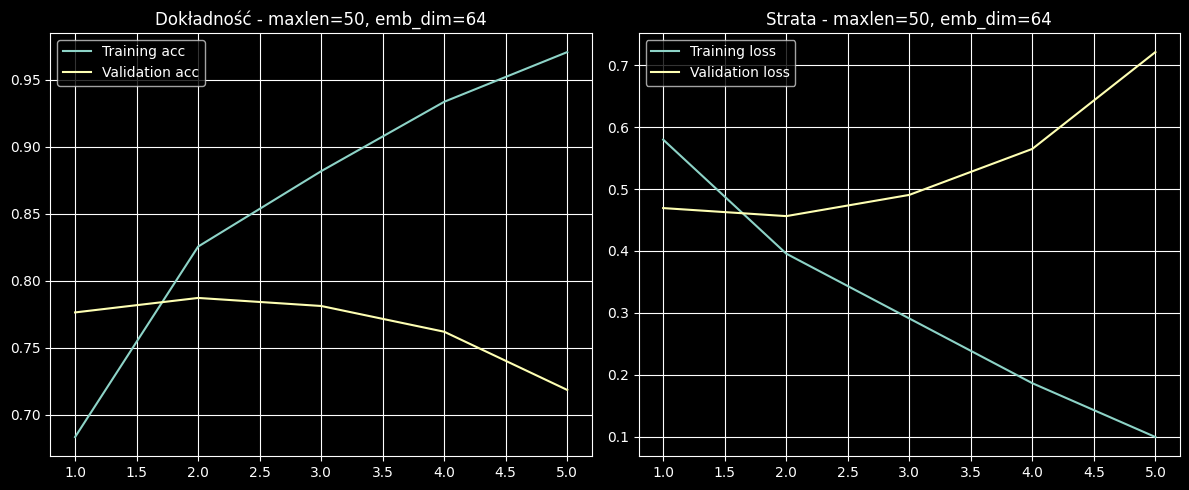

maxlen=50, emb=64 → val_acc=0.7186


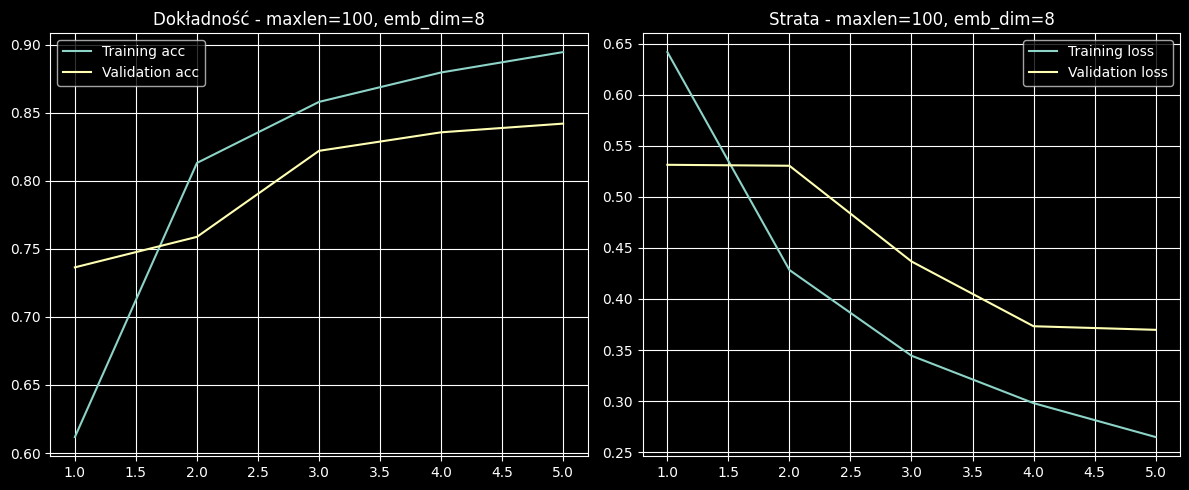

maxlen=100, emb=8 → val_acc=0.8420


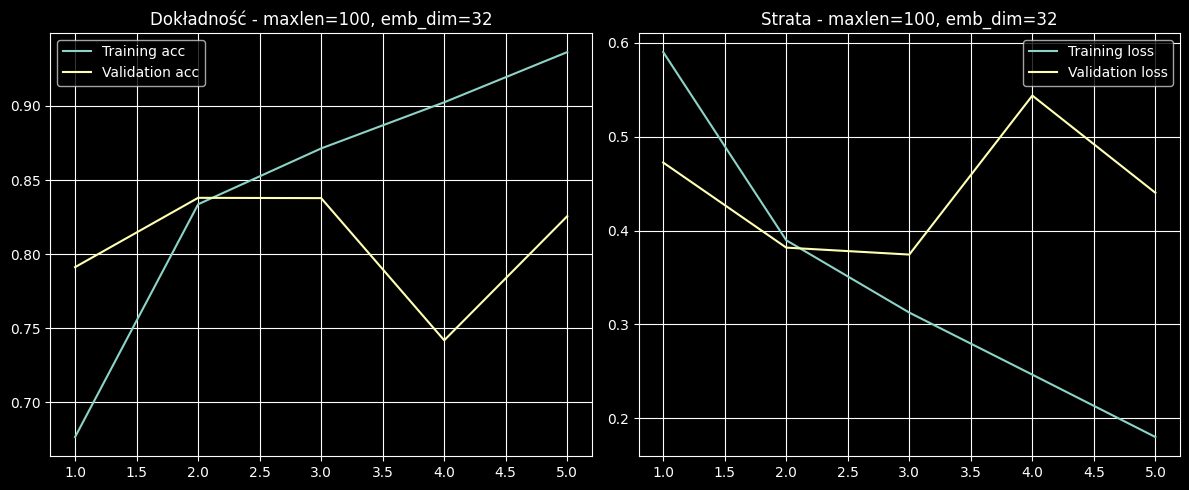

maxlen=100, emb=32 → val_acc=0.8256


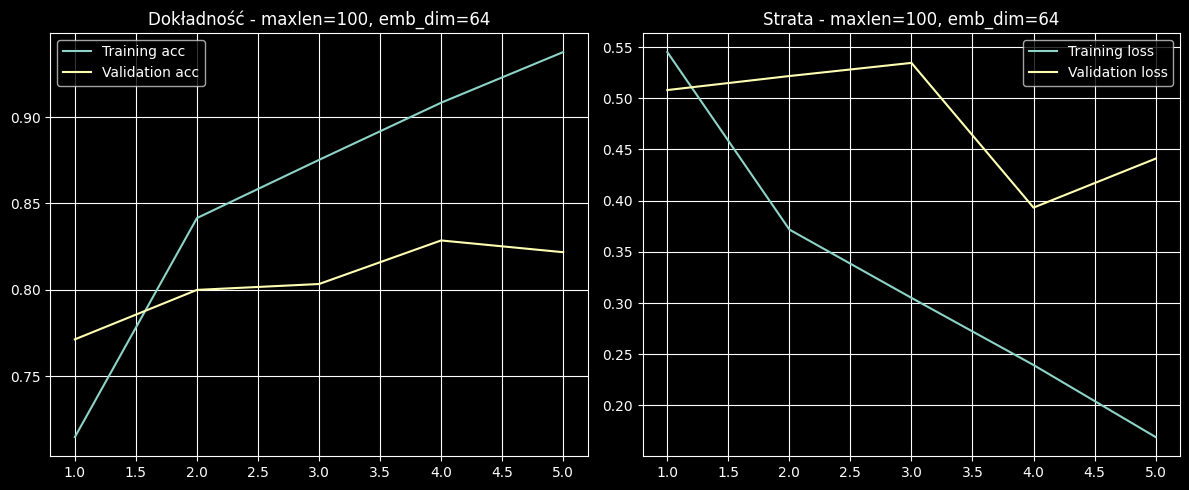

maxlen=100, emb=64 → val_acc=0.8218


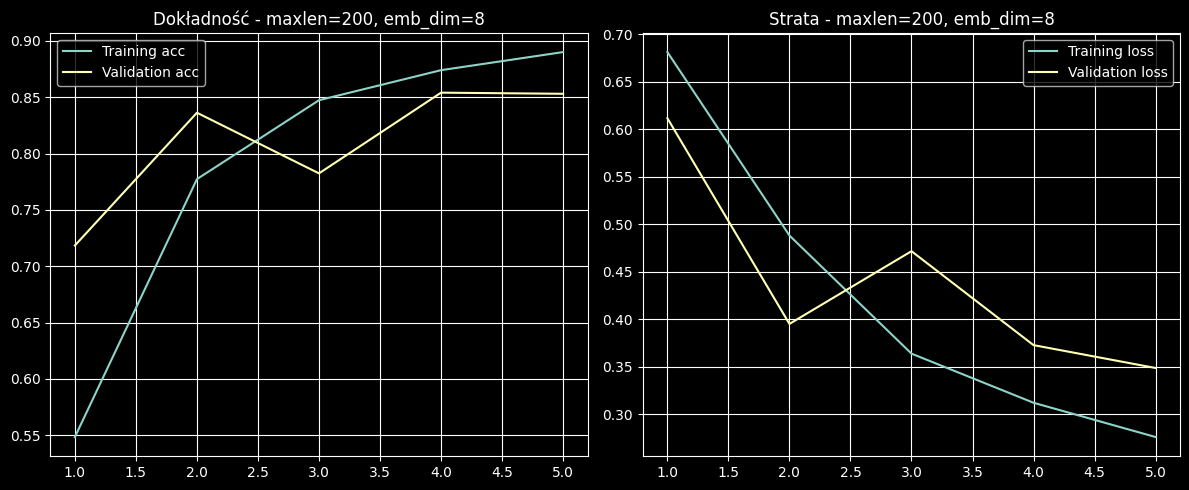

maxlen=200, emb=8 → val_acc=0.8530


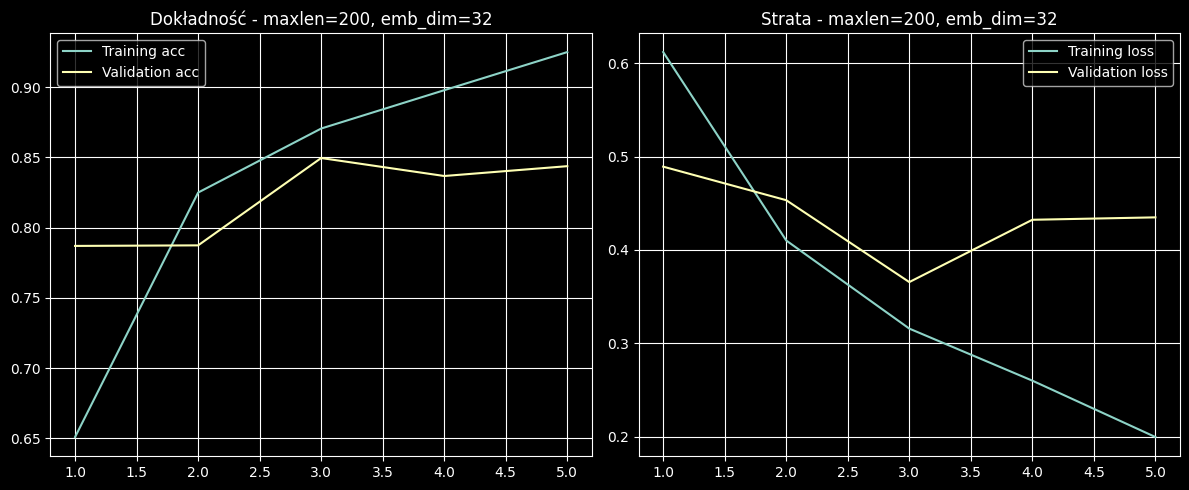

maxlen=200, emb=32 → val_acc=0.8438


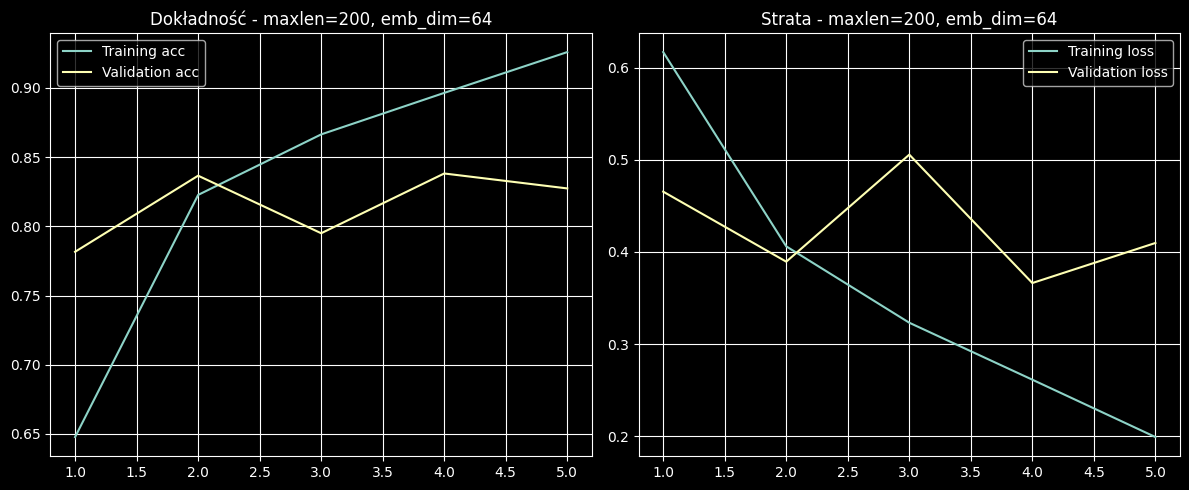

maxlen=200, emb=64 → val_acc=0.8274
[(20, 8, 0.7328000068664551), (20, 32, 0.6976000070571899), (20, 64, 0.7269999980926514), (50, 8, 0.777400016784668), (50, 32, 0.7343999743461609), (50, 64, 0.7185999751091003), (100, 8, 0.8420000076293945), (100, 32, 0.8256000280380249), (100, 64, 0.8217999935150146), (200, 8, 0.8529999852180481), (200, 32, 0.8438000082969666), (200, 64, 0.8274000287055969)]


In [31]:
results = []
for maxlen_test in [20, 50, 100, 200]:
    for emb_dim in [8, 32, 64]:
        x_train_pad = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen_test)

        model_test = Sequential()
        model_test.add(Input(shape=(maxlen_test,)))
        model_test.add(Embedding(max_features, emb_dim))
        model_test.add(SimpleRNN(32))
        model_test.add(Dense(1, activation='sigmoid'))

        model_test.compile(optimizer='rmsprop',
                           loss='binary_crossentropy',
                           metrics=['acc'])

        history_test = model_test.fit(x_train_pad, y_train,
                                      epochs=5,
                                      batch_size=128,
                                      validation_split=0.2,
                                      verbose=0)

        acc = history_test.history['acc']
        val_acc = history_test.history['val_acc']
        loss = history_test.history['loss']
        val_loss = history_test.history['val_loss']
        epochs = range(1, len(acc) + 1)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, acc, label='Training acc')
        plt.plot(epochs, val_acc, label='Validation acc')
        plt.title(f'Dokładność - maxlen={maxlen_test}, emb_dim={emb_dim}')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs, loss, label='Training loss')
        plt.plot(epochs, val_loss, label='Validation loss')
        plt.title(f'Strata - maxlen={maxlen_test}, emb_dim={emb_dim}')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

        final_val_acc = history_test.history['val_acc'][-1]
        results.append((maxlen_test, emb_dim, final_val_acc))
        print(f'maxlen={maxlen_test}, emb={emb_dim} → val_acc={final_val_acc:.4f}')

print(results)

#### Ćwiczenie 3

In [24]:
# Model z LSTM
model_lstm = Sequential()
model_lstm.add(Input(shape=(maxlen,)))
model_lstm.add(Embedding(max_features, 32))
model_lstm.add(LSTM(32))
model_lstm.add(Dense(1, activation='sigmoid'))
model_lstm.compile(optimizer='rmsprop',
                   loss='binary_crossentropy',
                   metrics=['acc'])
_ = model_lstm.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Trening
history_lstm = model_lstm.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

acc = history_lstm.history['acc']
val_acc = history_lstm.history['val_acc']
loss = history_lstm.history['loss']
val_loss = history_lstm.history['val_loss']
epochs = range(1, len(acc) + 1)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - acc: 0.6556 - loss: 0.6104 - val_acc: 0.7934 - val_loss: 0.4586
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - acc: 0.8225 - loss: 0.4087 - val_acc: 0.8312 - val_loss: 0.3824
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - acc: 0.8662 - loss: 0.3286 - val_acc: 0.8542 - val_loss: 0.3551
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - acc: 0.8810 - loss: 0.2998 - val_acc: 0.8486 - val_loss: 0.3872
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - acc: 0.8924 - loss: 0.2705 - val_acc: 0.8354 - val_loss: 0.3718
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - acc: 0.9018 - loss: 0.2477 - val_acc: 0.8776 - val_loss: 0.2906
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - acc: 0.9131 - loss: 0.2222 - val_acc: 0.8744 - val_loss: 0.3609
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - acc: 0.9186 - loss: 0.2096 - val_acc: 0.8618 - val_loss: 0.4417
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 

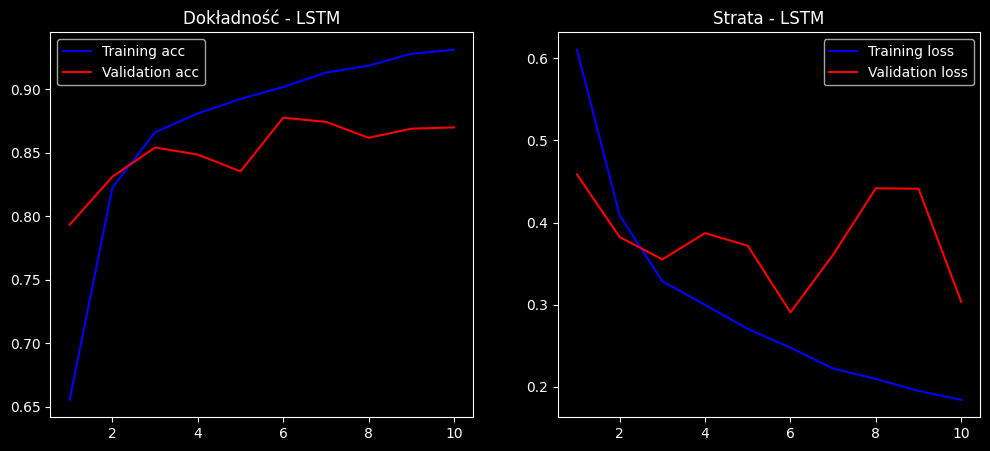

In [26]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Dokładność - LSTM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Strata - LSTM')
plt.legend()
plt.show()

#### Ćwiczenie 4

In [27]:
# Test SimpleRNN
model_rnn = Sequential()
model_rnn.add(Input(shape=(10, 2)))
model_rnn.add(SimpleRNN(1))
model_rnn.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_15 (SimpleRNN)       │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Test LSTM
model_lstm_test = Sequential()
model_lstm_test.add(Input(shape=(10, 2)))
model_lstm_test.add(LSTM(1))
model_lstm_test.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
print("Wyjaśnienie input_shape=(10, 2):")
print("10 = liczba kroków czasowych (timesteps)")
print("2  = liczba cech na każdy krok czasowy (features)")

Wyjaśnienie input_shape=(10, 2):
10 = liczba kroków czasowych (timesteps)
2  = liczba cech na każdy krok czasowy (features)
